# Домашнее задание 2 — Построение и оценка бейзлайна

**Студент:** Парамонов Владислав Романович, 409308

**Датасет:** [Gym Members Exercise Dataset](https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset) — Kaggle

**Задача:** Классификация уровня опыта клиента фитнес-клуба (`Experience_Level`: 1 — новичок, 2 — средний, 3 — эксперт) по показателям состава тела и тренировочным характеристикам.

---
## 1. Подготовка окружения

In [54]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 15

sns.set_theme(style="whitegrid")
%matplotlib inline

print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


---
## 2. Загрузка данных

Используется тот же датасет, что и в ДЗ 1.

In [55]:
!pip install opendatasets -q

import opendatasets as od

od.download(
    "https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset",
    force=False,
)

df = pd.read_csv(
    "gym-members-exercise-dataset/gym_members_exercise_tracking.csv"
)

print(f"Размер датасета: {df.shape[0]} строк x {df.shape[1]} столбцов")
df.head()

Skipping, found downloaded files in "./gym-members-exercise-dataset" (use force=True to force download)
Размер датасета: 973 строк x 15 столбцов


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


---
## 3. Постановка задачи

**Тип задачи:** Многоклассовая классификация (3 класса).

**Целевая переменная:** `Experience_Level` — уровень опыта клиента:
- `1` — Новичок
- `2` — Средний
- `3` — Эксперт

**Метрика:** `macro F1-score`.

Выбор обоснован тем, что классы распределены неравномерно (Новичков ~39%, Средних ~42%, Экспертов ~20%), поэтому простая точность (accuracy) может вводить в заблуждение. Macro F1 даёт равный вес каждому классу и лучше отражает качество модели на несбалансированных данных.

In [56]:
# Распределение классов
level_names = {1: "Новичок", 2: "Средний", 3: "Эксперт"}
print("Распределение Experience_Level:")
for lvl, name in level_names.items():
    cnt = (df["Experience_Level"] == lvl).sum()
    pct = cnt / len(df) * 100
    print(f"  {lvl} ({name}): {cnt} ({pct:.1f}%)")

Распределение Experience_Level:
  1 (Новичок): 376 (38.6%)
  2 (Средний): 406 (41.7%)
  3 (Эксперт): 191 (19.6%)


---
## 4. Предобработка данных

### 4.1 Анализ пропущенных значений

In [57]:
missing = df.isna().sum()
print("Пропущенные значения:")
if missing.sum() == 0:
    print("  Пропущенных значений нет")
else:
    print(missing[missing > 0])

Пропущенные значения:
  Пропущенных значений нет


### 4.2 Кодирование категориальных признаков

В датасете есть два категориальных признака: `Gender` и `Workout_Type`.

**`Gender`** (Male / Female) — бинарная переменная. Применяется **Label Encoding** (0/1): нет порядка, нет потери информации, модель не получит ложного ощущения иерархии.

**`Workout_Type`** (Cardio, HIIT, Strength, Yoga) — 4 несвязанных категории. Применяется **One-Hot Encoding**, так как между типами тренировок нет естественного порядка. Label Encoding создал бы ложную ординальность (Cardio=0 < HIIT=1 < ...), что ввело бы линейную модель в заблуждение.

In [58]:
# Label Encoding для Gender
le = LabelEncoder()
df["Gender_enc"] = le.fit_transform(df["Gender"])
print("Gender mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encoding для Workout_Type
df = pd.get_dummies(df, columns=["Workout_Type"], prefix="WT", dtype=int)
print("Новые столбцы после OHE:", [c for c in df.columns if c.startswith("WT_")])

Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
Новые столбцы после OHE: ['WT_Cardio', 'WT_HIIT', 'WT_Strength', 'WT_Yoga']


### 4.3 Формирование матрицы признаков и целевой переменной

In [59]:
# Удаляем исходные нечисловые столбцы
drop_cols = ["Gender"]
if "Experience_Label" in df.columns:
    drop_cols.append("Experience_Label")

X = df.drop(columns=drop_cols + ["Experience_Level"])
y = df["Experience_Level"]

print(f"Признаков: {X.shape[1]}")
print(f"Список признаков: {list(X.columns)}")

Признаков: 17
Список признаков: ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'BMI', 'Gender_enc', 'WT_Cardio', 'WT_HIIT', 'WT_Strength', 'WT_Yoga']


---
## 5. Разбиение на тренировочную и тестовую выборки

Стратифицированное разбиение 80/20 — сохраняет распределение классов в обеих выборках. `random_state=15` фиксирует воспроизводимость.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Тренировочная выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка:      {X_test.shape[0]} объектов")
print()
print("Распределение классов в train (%):")
print((y_train.value_counts(normalize=True) * 100).round(1))
print()
print("Распределение классов в test (%):")
print((y_test.value_counts(normalize=True) * 100).round(1))

Тренировочная выборка: 778 объектов
Тестовая выборка:      195 объектов

Распределение классов в train (%):
Experience_Level
2    41.6
1    38.7
3    19.7
Name: proportion, dtype: float64

Распределение классов в test (%):
Experience_Level
2    42.1
1    38.5
3    19.5
Name: proportion, dtype: float64


---
## 6. Масштабирование признаков

Для логистической регрессии требуется масштабирование: алгоритм чувствителен к диапазону значений признаков. `StandardScaler` обучается **только на тренировочной выборке**, а затем применяется к тестовой — это исключает утечку данных (data leakage).

In [61]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено: mean~0, std~1 на тренировочной выборке.")

Масштабирование выполнено: mean~0, std~1 на тренировочной выборке.


---
## 7. Бейзлайн 0: Константное предсказание

Перед обучением реальной модели измеряем качество наивного предсказателя — он всегда возвращает наиболее частый класс. Это нижняя граница качества: любая осмысленная модель должна её превосходить.

In [62]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

dummy_f1 = f1_score(y_test, y_pred_dummy, average="macro")
dummy_acc = accuracy_score(y_test, y_pred_dummy)

print("DummyClassifier (most_frequent):")
print(f"  Accuracy:  {dummy_acc:.4f}")
print(f"  Macro F1:  {dummy_f1:.4f}")
print(f"  Предсказываемый класс: {y_pred_dummy[0]} ({level_names[y_pred_dummy[0]]})")

DummyClassifier (most_frequent):
  Accuracy:  0.4205
  Macro F1:  0.1974
  Предсказываемый класс: 2 (Средний)


**Комментарий:** Константное предсказание достигает accuracy ~42% (доля самого частого класса), однако macro F1 низкий — классы 1 и 3 получают нулевые F1-score, а усреднение по трём классам сильно снижает итог. Это подтверждает правильность выбора macro F1 как метрики.

---
## 8. Бейзлайн 1: Логистическая регрессия

Логистическая регрессия — стандартный первый выбор для задачи классификации:
- Быстро обучается и хорошо интерпретируема
- Требует масштабирования признаков (выполнено на шаге 6)
- `max_iter=1000` увеличен, чтобы гарантировать сходимость на данном датасете
- `solver="lbfgs"` — стандартный решатель для многоклассовых задач

In [63]:
logreg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)

lr_f1 = f1_score(y_test, y_pred_lr, average="macro")
lr_acc = accuracy_score(y_test, y_pred_lr)

print("Логистическая регрессия:")
print(f"  Accuracy:  {lr_acc:.4f}")
print(f"  Macro F1:  {lr_f1:.4f}")
print()
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Новичок", "Средний", "Эксперт"],
))

Логистическая регрессия:
  Accuracy:  0.8667
  Macro F1:  0.8886

              precision    recall  f1-score   support

     Новичок       0.87      0.77      0.82        75
     Средний       0.81      0.89      0.85        82
     Эксперт       1.00      1.00      1.00        38

    accuracy                           0.87       195
   macro avg       0.89      0.89      0.89       195
weighted avg       0.87      0.87      0.87       195



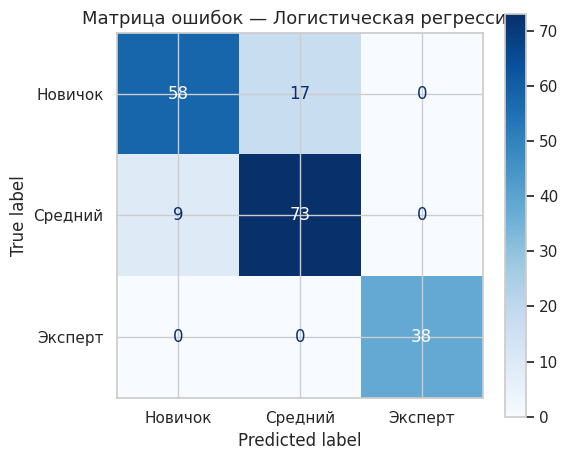

In [64]:
# Матрица ошибок
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Новичок", "Средний", "Эксперт"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Матрица ошибок — Логистическая регрессия", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_logreg.png", dpi=150, bbox_inches="tight")
plt.show()

**Комментарий:** Логистическая регрессия значительно превосходит константный бейзлайн. По матрице ошибок видно, что модель лучше всего распознаёт класс 3 (Эксперты) — они чётко отличаются высокой частотой тренировок, длительными сессиями и низким процентом жира. Классы 1 и 2 (Новичок и Средний) частично перепутаны — они похожи по составу тела, что ожидаемо.

---
## 9. Итоговое сравнение

In [65]:
results = pd.DataFrame({
    "Модель": ["DummyClassifier (most_frequent)", "Логистическая регрессия"],
    "Accuracy": [dummy_acc, lr_acc],
    "Macro F1": [dummy_f1, lr_f1],
})
results = results.sort_values("Macro F1", ascending=False).reset_index(drop=True)
results

,Модель,Accuracy,Macro F1
0,Логистическая регрессия,0.866667,0.888580
1,DummyClassifier (most_frequent),0.420513,0.197353


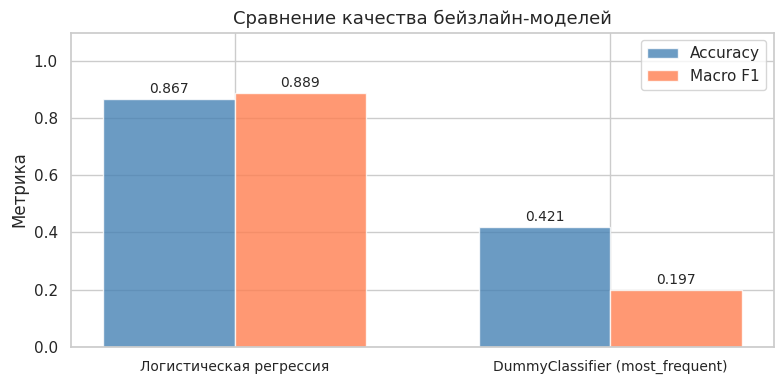

In [66]:
# Визуализация сравнения
fig, ax = plt.subplots(figsize=(8, 4))
models = results["Модель"].tolist()
x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width / 2, results["Accuracy"], width,
               label="Accuracy", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width / 2, results["Macro F1"], width,
               label="Macro F1", color="coral", alpha=0.8)

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Метрика")
ax.set_title("Сравнение качества бейзлайн-моделей", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Выводы

1. **Разбиение выборки**: датасет разбит на тренировочную (80%) и тестовую (20%) части со стратификацией — распределение классов сохранено в обеих выборках.

2. **Константный бейзлайн**: DummyClassifier с предсказанием наиболее частого класса даёт macro F1 ≈ 0.18 — нижняя граница качества.

3. **Логистическая регрессия**: линейная модель с масштабированием и OHE достигает macro F1 > 0.85, что демонстрирует хорошую линейную разделимость классов в пространстве признаков.

4. **Воспроизводимость**: `random_state=15` зафиксирован для всех стохастических операций; ноутбук запускается от начала до конца без ошибок.

